In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Standard Libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go


import warnings

# Configure warnings to display all warnings and ignore specific ones
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

print("Warnings are configured to show all and ignore specific warnings.")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,precision_score,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.utils import class_weight

from keras.models import Model
from keras.layers import Input, Conv1D, MaxPool1D, Flatten, Dense
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import text, sequence
from tensorflow.keras.layers import Dense, Dropout,LSTM, Activation,GRU,AveragePooling1D ,BatchNormalization, Reshape,Conv1D, MaxPooling1D,GlobalMaxPooling1D,Embedding

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras import layers

import keras_tuner
from keras_tuner import RandomSearch
from keras_tuner.tuners import Hyperband
from kerastuner import HyperParameters

Warnings are configured to show all and ignore specific warnings.


2025-11-14 17:55:18.216376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763142918.476414      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763142918.548273      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/nbaiot-dataset/7.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/9.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/5.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/1.mirai.udp.csv
/kaggle/input/nbaiot-dataset/4.gafgyt.udp.csv
/kaggle/input/nbaiot-dataset/6.gafgyt.udp.csv
/kaggle/input/nbaiot-dataset/6.gafgyt.junk.csv
/kaggle/input/nbaiot-dataset/data_summary.csv
/kaggle/input/nbaiot-dataset/5.gafgyt.udp.csv
/kaggle/input/nbaiot-dataset/9.gafgyt.junk.csv
/kaggle/input/nbaiot-dataset/9.mirai.scan.csv
/kaggle/input/nbaiot-dataset/1.benign.csv
/kaggle/input/nbaiot-dataset/2.mirai.udpplain.csv
/kaggle/input/nbaiot-dataset/3.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/4.gafgyt.combo.csv
/kaggle/input/nbaiot-dataset/6.mirai.scan.csv
/kaggle/input/nbaiot-dataset/5.mirai.udp.csv
/kaggle/input/nbaiot-dataset/3.benign.csv
/kaggle/input/nbaiot-dataset/3.gafgyt.junk.csv
/kaggle/input/nbaiot-dataset/7.gafgyt.scan.csv
/kaggle/input/nbaiot-dataset/features.csv
/kaggle/input/nbaiot-dataset/6

# Device Information

In [ ]:
device_info_dataframe=pd.read_csv("/kaggle/input/nbaiot-dataset/device_info.csv")
device_info_dataframe

,DeviceID,DeviceName
0,1,Danmini_Doorbell
1,2,Ecobee_Thermostat
2,3,Ennio_Doorbell
3,4,Philips_B120N10_Baby_Monitor
4,5,Provision_PT_737E_Security_Camera
5,6,Provision_PT_838_Security_Camera
6,7,Samsung_SNH_1011_N_Webcam
7,8,SimpleHome_XCS7_1002_WHT_Security_Camera
8,9,SimpleHome_XCS7_1003_WHT_Security_Camera


# Features of Data information

In [ ]:
features_data=pd.read_csv("/kaggle/input/nbaiot-dataset/features.csv")
features_data

,Feature Name,Feature Description
0,MI_dir_L5_weight,MI dir Lambda 5 weight
1,MI_dir_L5_mean,MI dir Lambda 5 mean
2,MI_dir_L5_variance,MI dir Lambda 5 variance
3,MI_dir_L3_weight,MI dir Lambda 3 weight
4,MI_dir_L3_mean,MI dir Lambda 3 mean
...,...,...
110,HpHp_L0.01_std,traffic going from this packet's host+port (IP...
111,HpHp_L0.01_magnitude,traffic going from this packet's host+port (IP...
112,HpHp_L0.01_radius,traffic going from this packet's host+port (IP...
113,HpHp_L0.01_covariance,traffic going from this packet's host+port (IP...


# Data summary

In [ ]:
Data_summary=pd.read_csv("/kaggle/input/nbaiot-dataset/data_summary.csv")
Data_summary

,File Name,Data Count,Feature Count
0,1.benign.csv,49548,115
1,1.gafgyt.combo.csv,59718,115
2,1.gafgyt.junk.csv,29068,115
3,1.gafgyt.scan.csv,29849,115
4,1.gafgyt.tcp.csv,92141,115
...,...,...,...
84,9.mirai.ack.csv,107187,115
85,9.mirai.scan.csv,43674,115
86,9.mirai.syn.csv,122479,115
87,9.mirai.udp.csv,157084,115


# Data Connection

In [ ]:
benign_df = pd.read_csv('../input/nbaiot-dataset/1.benign.csv')
m_a_df = pd.read_csv('../input/nbaiot-dataset/1.mirai.ack.csv')
m_sc_df = pd.read_csv('../input/nbaiot-dataset/1.mirai.scan.csv')
m_sy_df = pd.read_csv('../input/nbaiot-dataset/1.mirai.syn.csv')
m_u_df = pd.read_csv('../input/nbaiot-dataset/1.mirai.udp.csv')
m_u_p_df = pd.read_csv('../input/nbaiot-dataset/1.mirai.udpplain.csv')
g_c_df = pd.read_csv('../input/nbaiot-dataset/1.gafgyt.combo.csv')
g_j_df = pd.read_csv('../input/nbaiot-dataset/1.gafgyt.junk.csv')
g_s_df = pd.read_csv('../input/nbaiot-dataset/1.gafgyt.scan.csv')
g_t_df = pd.read_csv('../input/nbaiot-dataset/1.gafgyt.tcp.csv')
g_u_df = pd.read_csv('../input/nbaiot-dataset/1.gafgyt.udp.csv')



benign_df1 = pd.read_csv('../input/nbaiot-dataset/2.benign.csv')
m_a_df1 = pd.read_csv('../input/nbaiot-dataset/2.mirai.ack.csv')
m_sc_df1 = pd.read_csv('../input/nbaiot-dataset/2.mirai.scan.csv')
m_sy_df1 = pd.read_csv('../input/nbaiot-dataset/2.mirai.syn.csv')
m_u_df1 = pd.read_csv('../input/nbaiot-dataset/2.mirai.udp.csv')
m_u_p_df1 = pd.read_csv('../input/nbaiot-dataset/2.mirai.udpplain.csv')
g_c_df1 = pd.read_csv('../input/nbaiot-dataset/2.gafgyt.combo.csv')
g_j_df1 = pd.read_csv('../input/nbaiot-dataset/2.gafgyt.junk.csv')
g_s_df1 = pd.read_csv('../input/nbaiot-dataset/2.gafgyt.scan.csv')
g_t_df1 = pd.read_csv('../input/nbaiot-dataset/2.gafgyt.tcp.csv')
g_u_df1 = pd.read_csv('../input/nbaiot-dataset/2.gafgyt.udp.csv')

# Label the Datasets

To use these datasets in a classification model, you need to label each type of data:

* Benign data (normal traffic) label.
* Mirai and Gafgyt attack data specific labels.

In [ ]:
benign_df['Attack_Class'] = 'benign     '
m_u_df['Attack_Class']    = 'mirai_udp'
m_a_df['Attack_Class']    = 'mirai_ack'
m_sc_df['Attack_Class']   = 'mirai_scan'
m_sy_df['Attack_Class']   = 'mirai_syn'
m_u_p_df['Attack_Class']  = 'mirai_udpplain'
g_c_df['Attack_Class']    = 'gafgyt_combo'
g_j_df['Attack_Class']    = 'gafgyt_junk'
g_s_df['Attack_Class']    = 'gafgyt_scan'
g_t_df['Attack_Class']    = 'gafgyt_tcp'
g_u_df['Attack_Class']    = 'gafgyt_udp'


benign_df1['Attack_Class'] = 'benign     '
m_u_df1['Attack_Class']    = 'mirai_udp'
m_a_df1['Attack_Class']    = 'mirai_ack'
m_sc_df1['Attack_Class']   = 'mirai_scan'
m_sy_df1['Attack_Class']   = 'mirai_syn'
m_u_p_df1['Attack_Class']  = 'mirai_udpplain'
g_c_df1['Attack_Class']    = 'gafgyt_combo'
g_j_df1['Attack_Class']    = 'gafgyt_junk'
g_s_df1['Attack_Class']    = 'gafgyt_scan'
g_t_df1['Attack_Class']    = 'gafgyt_tcp'
g_u_df1['Attack_Class']    = 'gafgyt_udp'

# Combine the Datasets

Concatenate all labeled datasets into a single DataFrame. This allows you to split the data into training and testing sets for model training.

In [ ]:
df = pd.concat([benign_df,
                m_u_df, m_a_df, m_sc_df,m_sy_df, m_u_p_df,
                g_c_df,g_j_df, g_s_df, g_t_df,g_u_df,
                benign_df1,m_u_df1, m_a_df1, m_sc_df1,m_sy_df1, m_u_p_df1,
                g_c_df1,g_j_df1, g_s_df1, g_t_df1,g_u_df1],
                axis=0, sort=False, ignore_index=True)

In [ ]:
df.head(5)

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,Attack_Class
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,benign
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0,benign
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0,benign
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0,benign
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,benign


In [ ]:
# Sample 112,000 rows from the dataset for training
df = df.sample(n=312000, random_state=42)

# Display the first few rows to confirm
df.head()

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,Attack_Class
1140286,138.365721,494.314297,25922.354207,232.508798,464.527154,36194.195719,682.809357,442.443436,42663.808857,6433.711386,...,0.0,0.0,1.000000,554.0,0.000000,554.000000,0.000000e+00,0.0,0.0,mirai_udp
752811,180.825389,74.018189,0.436197,290.177688,74.028011,0.671476,819.090339,74.038594,0.925394,7445.956096,...,0.0,0.0,1.677116,74.0,0.000000,95.268043,0.000000e+00,0.0,0.0,gafgyt_combo
1850882,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.0,0.0,1.000000,60.0,0.000000,60.000000,0.000000e+00,0.0,0.0,gafgyt_udp
301120,140.692707,434.343643,49238.478144,234.006662,408.543959,54851.135449,674.134985,394.289144,57390.413196,6311.213623,...,0.0,0.0,1.000000,566.0,0.000000,566.000000,0.000000e+00,0.0,0.0,mirai_ack
627917,106.905918,333.986238,60280.742829,182.118784,322.823278,60758.607635,533.316020,330.450422,60458.038637,4939.332006,...,0.0,0.0,8023.788416,554.0,0.000023,554.000000,5.238689e-10,0.0,0.0,mirai_udpplain


# Data Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312000 entries, 1140286 to 790768
Columns: 116 entries, MI_dir_L5_weight to Attack_Class
dtypes: float64(115), object(1)
memory usage: 278.5+ MB


In [ ]:
df.groupby('Attack_Class')['Attack_Class'].count()

Attack_Class
benign            10573
gafgyt_combo      18941
gafgyt_junk       10051
gafgyt_scan        9516
gafgyt_tcp        31546
gafgyt_udp        35569
mirai_ack         36424
mirai_scan        25387
mirai_syn         40455
mirai_udp         65152
mirai_udpplain    28386
Name: Attack_Class, dtype: int64

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MI_dir_L5_weight,312000.0,96.132600,66.138641,1.000000,5.000680e+00,111.931229,149.230508,438.002839
MI_dir_L5_mean,312000.0,205.020857,175.304050,60.000000,6.000000e+01,74.055730,369.208014,1094.290968
MI_dir_L5_variance,312000.0,18383.125604,24448.398259,0.000000,6.366463e-12,38.792781,43885.265697,183415.194100
MI_dir_L3_weight,312000.0,153.141980,104.818381,1.000000,7.076557e+00,188.236969,235.962504,502.808549
MI_dir_L3_mean,312000.0,205.267580,169.447765,60.000000,6.000002e+01,74.070869,378.817916,1042.887364
...,...,...,...,...,...,...,...,...
HpHp_L0.01_std,312000.0,0.858972,12.061948,0.000000,0.000000e+00,0.000000,0.000000,310.122849
HpHp_L0.01_magnitude,312000.0,208.462365,221.471564,60.000000,6.000000e+01,74.000000,554.000000,1278.265351
HpHp_L0.01_radius,312000.0,256.817343,4610.874876,0.000000,0.000000e+00,0.000000,0.000000,356941.159600
HpHp_L0.01_covariance,312000.0,-16.048989,785.276318,-29650.840960,0.000000e+00,0.000000,0.000000,107530.507775


In [ ]:
df.describe(include='object')

,Attack_Class
count,312000
unique,11
top,mirai_udp
freq,65152


In [ ]:
df.shape

(312000, 116)

# Exploration Data Analysis

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
df.isnull().sum()

MI_dir_L5_weight         0
MI_dir_L5_mean           0
MI_dir_L5_variance       0
MI_dir_L3_weight         0
MI_dir_L3_mean           0
                        ..
HpHp_L0.01_magnitude     0
HpHp_L0.01_radius        0
HpHp_L0.01_covariance    0
HpHp_L0.01_pcc           0
Attack_Class             0
Length: 116, dtype: int64

In [ ]:
df.duplicated().sum()

10013

## Distribution of Attack Classes

In [ ]:
attack_counts = df['Attack_Class'].value_counts().reset_index()
attack_counts.columns = ['Attack_Class', 'Count']

fig = px.bar(attack_counts, x='Attack_Class', y='Count', title="Distribution of Attack Classes")
fig.show()

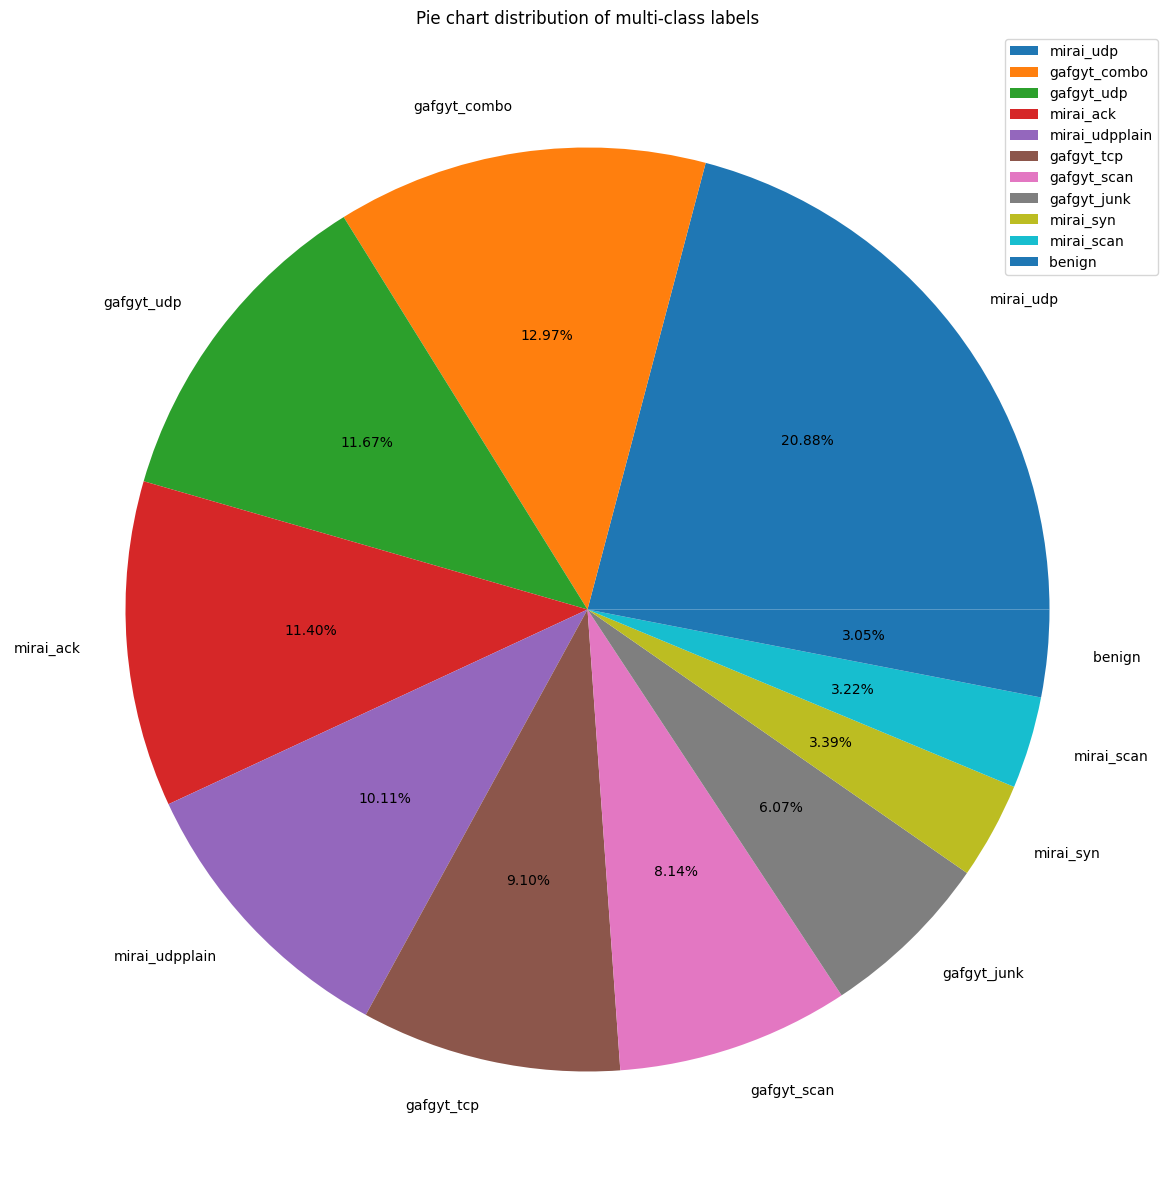

In [ ]:
plt.figure(figsize=(15,15))
plt.pie(df['Attack_Class'].value_counts(),autopct='%0.2f%%',labels=df.Attack_Class.unique())
plt.title('Pie chart distribution of multi-class labels')
plt.legend()
plt.show()

## Distribution of Numerical Features

In [ ]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
#for col in numerical_columns:
    #fig = px.histogram(df, x=col, title=f"Distribution of {col}")
    #fig.show()

## Correlation Heatmap

In [ ]:
correlation_matrix = df[numerical_columns].corr()

fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='Viridis'))
fig.update_layout(title='Correlation Heatmap of Numerical Features')
fig.show()


# Data Preprocessing

## Handling Duplicates

In [ ]:
print(df.duplicated().sum(), "fully duplicate rows to remove")
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True, drop=True)
df.shape

10013 fully duplicate rows to remove


(301987, 116)

In [ ]:
import os, joblib, math
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample, class_weight
from sklearn.model_selection import train_test_split
np.random.seed(42)
print("Imports loaded.")


Imports loaded.


In [ ]:
# Use existing combined df if present; otherwise try to stitch from fragment DataFrames in the kernel.
if 'df' in globals() and isinstance(df, pd.DataFrame):
    print("Using existing 'df' (shape):", df.shape)
else:
    cand = [name for name,val in globals().items() if isinstance(val, pd.DataFrame) and any(k in name.lower() for k in ['benign','mirai','gafgyt','m_a','m_u','g_','m_sc','m_sy'])]
    if len(cand) == 0:
        raise RuntimeError("No DataFrame fragments found in kernel. Load CSVs first.")
    frames = []
    for name in cand:
        part = globals()[name].copy()
        if 'Attack_Class' not in part.columns:
            ln = name.lower()
            if 'benign' in ln:
                lab = 'benign'
            elif 'mirai' in ln:
                lab = 'mirai'
            elif 'gafgyt' in ln:
                lab = 'gafgyt'
            else:
                lab = ln
            part['Attack_Class'] = lab
        frames.append(part)
    df = pd.concat(frames, ignore_index=True, sort=False)
    print("Rebuilt df from fragments. shape:", df.shape)

# Normalize Attack_Class and create label later
df['Attack_Class'] = df['Attack_Class'].astype(str).str.strip().str.lower()
print("Attack_Class sample counts:\n", df['Attack_Class'].value_counts().head(20))


Using existing 'df' (shape): (301987, 116)
Attack_Class sample counts:
 Attack_Class
mirai_udp         65152
mirai_syn         40455
mirai_ack         36424
gafgyt_udp        32297
mirai_udpplain    28386
gafgyt_tcp        28243
mirai_scan        25387
gafgyt_combo      17425
benign            10197
gafgyt_junk        9267
gafgyt_scan        8754
Name: count, dtype: int64


In [ ]:
# Detect numeric features (with light coercion) and label
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Try coercion for mostly-numeric columns
candidates = [c for c in df.columns if c not in numeric_cols and c not in ['Attack_Class']]
coerced = []
for c in candidates:
    coerced_col = pd.to_numeric(df[c], errors='coerce')
    if coerced_col.notnull().mean() >= 0.60:
        df[c] = coerced_col
        coerced.append(c)
if coerced:
    print("Coerced to numeric:", coerced)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'label']

# drop constants & >80% missing numeric cols
drops = []
for c in numeric_cols:
    if df[c].nunique(dropna=True) <= 1:
        drops.append(c)
    if df[c].isnull().mean() > 0.80:
        drops.append(c)
features = [c for c in numeric_cols if c not in drops]

if len(features) == 0:
    raise RuntimeError("No numeric features detected. Inspect your dataset.")

# Binary label 0 = benign, 1 = attack
df['label'] = (df['Attack_Class'] != 'benign').astype(int)

# detect group and time columns heuristically
possible_group_cols = ['device','device_id','src_ip','srcip','src','ip_src','mac','id','dst','dst_ip']
group_col = next((c for c in possible_group_cols if c in df.columns), None)
time_col = None
for c in df.columns:
    if any(k in c.lower() for k in ['time','ts','timestamp','date','epoch']):
        try:
            pd.to_datetime(df[c].iloc[:200], errors='raise')
            time_col = c
            break
        except Exception:
            continue

print("Selected feature count:", len(features))
print("Detected group_col:", group_col, "time_col:", time_col)
print("Global label counts:", df['label'].value_counts().to_dict())


Selected feature count: 115
Detected group_col: None time_col: None
Global label counts: {1: 291790, 0: 10197}


In [ ]:
# Flow-level stratified split (for CNN)
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-6

def stratified_flow_split(df, train_frac=0.7, val_frac=0.15, test_frac=0.15, seed=42):
    parts = {'train': [], 'val': [], 'test': []}
    for label in sorted(df['label'].unique()):
        sub = df[df['label']==label].sample(frac=1, random_state=seed).reset_index(drop=True)
        n = len(sub)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_test = n - n_train - n_val
        i = 0
        parts['train'].append(sub.iloc[i:i+n_train]); i += n_train
        parts['val'].append(sub.iloc[i:i+n_val]); i += n_val
        parts['test'].append(sub.iloc[i:i+n_test])
    train_df = pd.concat(parts['train'], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df   = pd.concat(parts['val'], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df  = pd.concat(parts['test'], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = stratified_flow_split(df, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, seed=42)

print("Flow split shapes (train,val,test):", train_df.shape, val_df.shape, test_df.shape)
print("Flow split label counts:")
print("train:", train_df['label'].value_counts().to_dict())
print("val:  ", val_df['label'].value_counts().to_dict())
print("test: ", test_df['label'].value_counts().to_dict())


Flow split shapes (train,val,test): (211391, 117) (45298, 117) (45298, 117)
Flow split label counts:
train: {1: 204253, 0: 7138}
val:   {1: 43768, 0: 1530}
test:  {1: 43769, 0: 1529}


In [ ]:
from sklearn.preprocessing import StandardScaler

# median impute using train medians
median_vals = train_df[features].median()
train_df[features] = train_df[features].fillna(median_vals)
val_df[features]   = val_df[features].fillna(median_vals)
test_df[features]  = test_df[features].fillna(median_vals)

scaler_cnn = StandardScaler()
scaler_cnn.fit(train_df[features].values)

X_train_flows = scaler_cnn.transform(train_df[features].values)
X_val_flows   = scaler_cnn.transform(val_df[features].values)
X_test_flows  = scaler_cnn.transform(test_df[features].values)

y_train_flows = train_df['label'].values.astype(int)
y_val_flows   = val_df['label'].values.astype(int)
y_test_flows  = test_df['label'].values.astype(int)

# reshape for Conv1D: (samples, features, 1)
n_feat = X_train_flows.shape[1]
X_train_cnn = X_train_flows.reshape((-1, n_feat, 1))
X_val_cnn   = X_val_flows.reshape((-1, n_feat, 1))
X_test_cnn  = X_test_flows.reshape((-1, n_feat, 1))

classes_flow = np.unique(y_train_flows)
cw_vals = class_weight.compute_class_weight('balanced', classes=classes_flow, y=y_train_flows)
class_weights_flow = {int(c): float(w) for c,w in zip(classes_flow, cw_vals)}

print("CNN shapes:", X_train_cnn.shape, X_val_cnn.shape, X_test_cnn.shape)
print("CNN train label counts:", np.bincount(y_train_flows))


CNN shapes: (211391, 115, 1) (45298, 115, 1) (45298, 115, 1)
CNN train label counts: [  7138 204253]


In [ ]:
# Build all sliding windows over the full dataset (global_time recommended).
# LABEL_METHOD options: 'any_benign' (benign if any benign row present) or 'threshold' (fraction_attack >= THRESHOLD -> attack)
LABEL_METHOD = 'any_benign'   # safe default to ensure benign windows exist
THRESHOLD = 0.05              # used if LABEL_METHOD == 'threshold'
SEQ_LEN = 50
STEP = 5
WINDOW_MODE = 'global_time'   # 'global_time' or 'group' or 'global'
print("Building all windows with LABEL_METHOD =", LABEL_METHOD, "SEQ_LEN", SEQ_LEN, "STEP", STEP, "WINDOW_MODE", WINDOW_MODE)

def build_all_sequence_windows(df_all, features, seq_len=50, step=5, mode='global_time', time_col_var=None, group_col_var=None, label_method='any_benign', threshold=0.05):
    rows = df_all.reset_index(drop=True)
    if mode=='global_time' and time_col_var is not None:
        tmp = rows.copy()
        tmp[time_col_var] = pd.to_datetime(tmp[time_col_var], errors='coerce')
        tmp = tmp.sort_values(time_col_var).reset_index(drop=True)
        rows = tmp
    Xw, yw = [], []
    if mode == 'group' and group_col_var is not None and group_col_var in rows.columns:
        for g, sub in rows.groupby(group_col_var):
            sub = sub.reset_index(drop=True)
            feat_arr = sub[features].values
            labels = sub['label'].values
            for start in range(0, len(sub)-seq_len+1, step):
                window_labels = labels[start:start+seq_len]
                window_feats = feat_arr[start:start+seq_len]
                if label_method == 'any_benign':
                    lab = 0 if (window_labels==0).any() else 1
                else:
                    lab = 1 if window_labels.mean() >= threshold else 0
                Xw.append(window_feats); yw.append(lab)
    else:
        feat_arr = rows[features].values
        labels = rows['label'].values
        for start in range(0, len(rows)-seq_len+1, step):
            window_labels = labels[start:start+seq_len]
            window_feats = feat_arr[start:start+seq_len]
            if label_method == 'any_benign':
                lab = 0 if (window_labels==0).any() else 1
            else:
                lab = 1 if window_labels.mean() >= threshold else 0
            Xw.append(window_feats); yw.append(lab)
    if len(Xw) == 0:
        return np.empty((0, seq_len, len(features))), np.empty((0,))
    return np.array(Xw), np.array(yw)

# Build windows on the full df
X_seq_all, y_seq_all = build_all_sequence_windows(df, features, seq_len=SEQ_LEN, step=STEP, mode=WINDOW_MODE, time_col_var=time_col, group_col_var=group_col, label_method=LABEL_METHOD, threshold=THRESHOLD)
print("All windows built:", X_seq_all.shape, "label counts:", dict(zip(*np.unique(y_seq_all, return_counts=True))) if y_seq_all.size>0 else None)


Building all windows with LABEL_METHOD = any_benign SEQ_LEN 50 STEP 5 WINDOW_MODE global_time
All windows built: (60388, 50, 115) label counts: {0: 49382, 1: 11006}


In [ ]:
# Stratified split of sequence windows
assert X_seq_all.shape[0] > 0, "No sequence windows built — adjust SEQ_LEN/STEP/MODE."

SEQ_TRAIN_FRAC = 0.70
SEQ_VAL_FRAC = 0.15
SEQ_TEST_FRAC = 0.15

# first train / temp
X_train_seq, X_temp, y_train_seq, y_temp = train_test_split(
    X_seq_all, y_seq_all, test_size=(1-SEQ_TRAIN_FRAC), stratify=y_seq_all, random_state=42
)

# then val / test split from temp
rel_test_frac = SEQ_TEST_FRAC / (SEQ_VAL_FRAC + SEQ_TEST_FRAC)
X_val_seq, X_test_seq, y_val_seq, y_test_seq = train_test_split(
    X_temp, y_temp, test_size=rel_test_frac, stratify=y_temp, random_state=42
)

print("Sequence splits shapes (train/val/test):", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print("Sequence label counts (train/val/test):", np.bincount(y_train_seq.astype(int)), np.bincount(y_val_seq.astype(int)), np.bincount(y_test_seq.astype(int)))


Sequence splits shapes (train/val/test): (42271, 50, 115) (9058, 50, 115) (9059, 50, 115)
Sequence label counts (train/val/test): [34567  7704] [7407 1651] [7408 1651]


In [ ]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on flattened training windows
n_seq, seq_len_local, n_feat = X_train_seq.shape
scaler_seq = StandardScaler()
scaler_seq.fit(X_train_seq.reshape(-1, n_feat))

# transform sets
X_train_seq = scaler_seq.transform(X_train_seq.reshape(-1, n_feat)).reshape(-1, seq_len_local, n_feat)
X_val_seq   = scaler_seq.transform(X_val_seq.reshape(-1, n_feat)).reshape(-1, seq_len_local, n_feat)
X_test_seq  = scaler_seq.transform(X_test_seq.reshape(-1, n_feat)).reshape(-1, seq_len_local, n_feat)

print("Scaled sequences. dims:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

# optional balancing of training sequences
BALANCE_SEQ = 'down'  # options: 'down', 'up', 'none'
if BALANCE_SEQ == 'down':
    idx_pos = np.where(y_train_seq==1)[0]; idx_neg = np.where(y_train_seq==0)[0]
    if len(idx_pos)>0 and len(idx_neg)>0:
        n_keep = min(len(idx_pos), len(idx_neg))
        idx_pos_s = resample(idx_pos, replace=False, n_samples=n_keep, random_state=42)
        idx_neg_s = resample(idx_neg, replace=False, n_samples=n_keep, random_state=42)
        idx_keep = np.concatenate([idx_pos_s, idx_neg_s])
        np.random.shuffle(idx_keep)
        X_train_seq = X_train_seq[idx_keep]; y_train_seq = y_train_seq[idx_keep]
elif BALANCE_SEQ == 'up':
    idx_pos = np.where(y_train_seq==1)[0]; idx_neg = np.where(y_train_seq==0)[0]
    if len(idx_pos)>0 and len(idx_neg)>0:
        n_target = max(len(idx_pos), len(idx_neg))
        pos_up = resample(X_train_seq[idx_pos], replace=True, n_samples=n_target, random_state=42)
        neg_up = resample(X_train_seq[idx_neg], replace=True, n_samples=n_target, random_state=42)
        X_train_seq = np.concatenate([pos_up, neg_up], axis=0)
        y_train_seq = np.concatenate([np.ones(n_target), np.zeros(n_target)], axis=0)
        p = np.random.permutation(len(y_train_seq)); X_train_seq, y_train_seq = X_train_seq[p], y_train_seq[p]
else:
    pass

print("After balancing (if applied) train seq shape and counts:", X_train_seq.shape, np.bincount(y_train_seq.astype(int)))


Scaled sequences. dims: (42271, 50, 115) (9058, 50, 115) (9059, 50, 115)
After balancing (if applied) train seq shape and counts: (15408, 50, 115) [7704 7704]


In [ ]:
# compute class weights if we didn't balance (helpful for training)
class_weights_seq = None
if BALANCE_SEQ == 'none':
    classes_seq = np.unique(y_train_seq)
    cw_seq_vals = class_weight.compute_class_weight('balanced', classes=classes_seq, y=y_train_seq)
    class_weights_seq = {int(c): float(w) for c,w in zip(classes_seq, cw_seq_vals)}

# ensure class_weights_flow exists (from earlier)
classes_flow = np.unique(y_train_flows)
cw_vals_flow = class_weight.compute_class_weight('balanced', classes=classes_flow, y=y_train_flows)
class_weights_flow = {int(c): float(w) for c,w in zip(classes_flow, cw_vals_flow)}

artifacts = {
    'features': features,
    'group_col': group_col,
    'time_col': time_col,
    'scaler_cnn': scaler_cnn,
    'scaler_seq': scaler_seq,
    'X_train_cnn': X_train_cnn, 'X_val_cnn': X_val_cnn, 'X_test_cnn': X_test_cnn,
    'y_train_flows': y_train_flows, 'y_val_flows': y_val_flows, 'y_test_flows': y_test_flows,
    'X_train_seq': X_train_seq, 'y_train_seq': y_train_seq, 'X_val_seq': X_val_seq, 'y_val_seq': y_val_seq,
    'X_test_seq': X_test_seq, 'y_test_seq': y_test_seq,
    'class_weights_flow': class_weights_flow, 'class_weights_seq': class_weights_seq,
    'SEQ_LEN': SEQ_LEN, 'STEP': STEP,
    'LABEL_METHOD': LABEL_METHOD, 'THRESHOLD': THRESHOLD, 'WINDOW_MODE': WINDOW_MODE, 'BALANCE_SEQ': BALANCE_SEQ
}

joblib.dump(artifacts, "preproc_stratified_final.joblib")
print("Saved preproc_stratified_final.joblib")

# Final diagnostics
print("\nFINAL DIAGNOSTICS:")
print("CNN (train,val,test):", X_train_cnn.shape, X_val_cnn.shape, X_test_cnn.shape)
print("CNN flow labels train:", np.bincount(y_train_flows))
print("SEQ (train,val,test):", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print("SEQ labels (train,val,test):", np.bincount(y_train_seq.astype(int)), np.bincount(y_val_seq.astype(int)), np.bincount(y_test_seq.astype(int)))
print("class_weights_flow:", class_weights_flow)
print("class_weights_seq:", class_weights_seq)


Saved preproc_stratified_final.joblib

FINAL DIAGNOSTICS:
CNN (train,val,test): (211391, 115, 1) (45298, 115, 1) (45298, 115, 1)
CNN flow labels train: [  7138 204253]
SEQ (train,val,test): (15408, 50, 115) (9058, 50, 115) (9059, 50, 115)
SEQ labels (train,val,test): [7704 7704] [7407 1651] [7408 1651]
class_weights_flow: {0: 14.80743905855982, 1: 0.5174734275628754}
class_weights_seq: None


# Model Development

In [ ]:
# shared imports and helpers
import joblib, os, math, time
import numpy as np, pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
np.random.seed(42)
tf.random.set_seed(42)

def plot_history(history, title="history"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history.get('accuracy',[]), label='train_acc')
    plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
    plt.title('Accuracy - '+title); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history.get('loss',[]), label='train_loss')
    plt.plot(history.history.get('val_loss',[]), label='val_loss')
    plt.title('Loss - '+title); plt.legend()
    plt.show()

def eval_and_print(model, X_test, y_test, batch_size=1024, binary=True):
    if X_test.shape[0] == 0:
        print("Empty test set.")
        return
    if binary:
        y_prob = model.predict(X_test, batch_size=batch_size).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("F1:", f1_score(y_test, y_pred))
        try:
            print("AUC:", roc_auc_score(y_test, y_prob))
        except Exception as e:
            print("AUC error:", e)
    else:
        y_prob = model.predict(X_test, batch_size=batch_size)
        y_pred = np.argmax(y_prob, axis=1)
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


## 1D-CNN (flow-level) baseline

Shapes: (211391, 115, 1) (45298, 115, 1) (45298, 115, 1)


2025-11-14 18:07:19.012808: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 115, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 115, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 115, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 57, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 57, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,537 (131.00 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
413/413 - 55s - 133ms/step - accuracy: 0.9487 - auc: 0.9959 - loss: 0.1030 - val_accuracy: 0.9983 - val_auc: 0.9993 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 2/50
413/413 - 42s - 102ms/step - accuracy: 0.9970 - auc: 0.9994 - loss: 0.0247 - val_accuracy: 0.9979 - val_auc: 0.9993 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 3/50
413/413 - 42s - 101ms/step - accuracy: 0.9981 - auc: 0.9996 - loss: 0.0173 - val_accuracy: 0.9970 - val_auc: 0.9993 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 4/50
413/413 - 42s - 102ms/step - accuracy: 0.9973 - auc: 0.9995 - loss: 0.0214 - val_accuracy: 0.9983 - val_auc: 0.9998 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 5/50
413/413 - 42s - 101ms/step - accuracy: 0.9987 - auc: 0.9998 - loss: 0.0131 - val_accuracy: 0.9979 - val_auc: 0.9997 - val_loss: 0.0187 - learning_rate: 5.0000e-04
Epoch 6/50
413/413 - 42s - 103ms/step - accuracy: 0.9983 - auc: 0.9997 - loss: 0.0135 - val_accuracy: 0.9981 - val_auc: 0.9999 - val_loss: 0.0107 

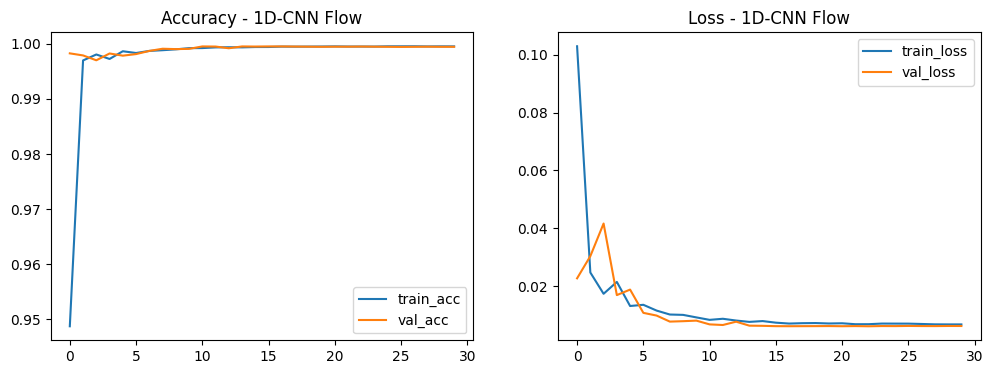

Saved model: final_1dcnn_flow.keras


In [ ]:
# 1D-CNN baseline (flow-level)
art = joblib.load("preproc_stratified_final.joblib")
X_train_cnn = art['X_train_cnn']; X_val_cnn = art['X_val_cnn']; X_test_cnn = art['X_test_cnn']
y_train_flows = art['y_train_flows']; y_val_flows = art['y_val_flows']; y_test_flows = art['y_test_flows']
class_weights_flow = art['class_weights_flow']

n_features = X_train_cnn.shape[1]
n_classes = 2
print("Shapes:", X_train_cnn.shape, X_val_cnn.shape, X_test_cnn.shape)

def build_1dcnn(n_features):
    inp = layers.Input(shape=(n_features,1))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

model_cnn = build_1dcnn(n_features)
model_cnn.summary()

es = callbacks.EarlyStopping(monitor='val_auc', patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6)
ckpt = callbacks.ModelCheckpoint("model_1dcnn_flow.keras", save_best_only=True, monitor='val_auc')

history = model_cnn.fit(
    X_train_cnn, y_train_flows,
    validation_data=(X_val_cnn, y_val_flows),
    epochs=50,
    batch_size=512,
    callbacks=[es, rlr, ckpt],
    class_weight=class_weights_flow,
    verbose=2
)

# final save (safe to overwrite)
model_cnn.save("final_1dcnn_flow.keras")

# evaluate
eval_and_print(model_cnn, X_test_cnn, y_test_flows, batch_size=1024, binary=True)
plot_history(history, "1D-CNN Flow")
print("Saved model: final_1dcnn_flow.keras")


## LSTM baseline (sequence-level)

Shapes: (15408, 50, 115) (9058, 50, 115) (9059, 50, 115)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50, 115)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        22,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,481 (392.50 KB)

 Trainable params: 100,481 (392.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
121/121 - 13s - 105ms/step - accuracy: 0.8001 - auc: 0.8964 - loss: 0.4242 - val_accuracy: 0.9811 - val_auc: 0.9941 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 2/50
121/121 - 5s - 43ms/step - accuracy: 0.9823 - auc: 0.9963 - loss: 0.0808 - val_accuracy: 0.9919 - val_auc: 0.9989 - val_loss: 0.0463 - learning_rate: 0.0010
Epoch 3/50
121/121 - 5s - 43ms/step - accuracy: 0.9930 - auc: 0.9989 - loss: 0.0425 - val_accuracy: 0.9941 - val_auc: 0.9986 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 4/50
121/121 - 5s - 43ms/step - accuracy: 0.9951 - auc: 0.9991 - loss: 0.0353 - val_accuracy: 0.9970 - val_auc: 0.9992 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 5/50
121/121 - 5s - 43ms/step - accuracy: 0.9970 - auc: 0.9995 - loss: 0.0267 - val_accuracy: 0.9956 - val_auc: 0.9989 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 6/50
121/121 - 5s - 43ms/step - accuracy: 0.9977 - auc: 0.9995 - loss: 0.0230 - val_accuracy: 0.9970 - val_auc: 0.9991 - val_loss: 0.0263 - learning_rat

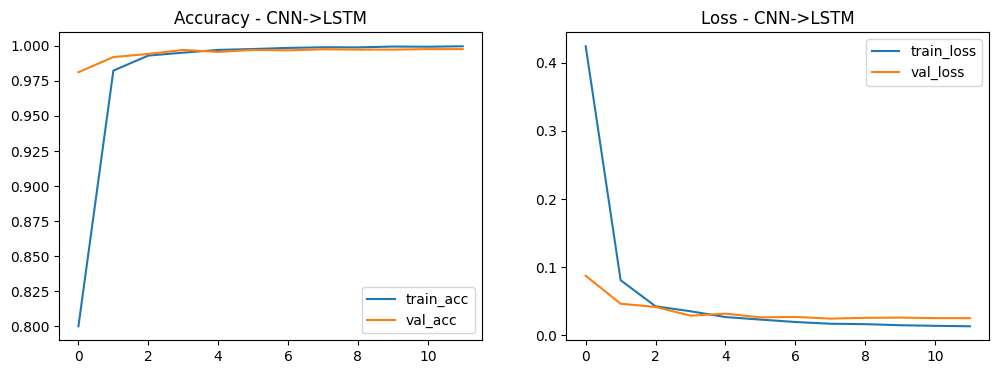

Saved model: final_cnn_lstm_seq.keras


In [ ]:
# CNN -> LSTM baseline (sequence windows)
art = joblib.load("preproc_stratified_final.joblib")
X_train_seq = art['X_train_seq']; y_train_seq = art['y_train_seq']
X_val_seq = art['X_val_seq']; y_val_seq = art['y_val_seq']
X_test_seq = art['X_test_seq']; y_test_seq = art['y_test_seq']
class_weights_seq = art.get('class_weights_seq', None)

print("Shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

def build_cnn_lstm(seq_len, n_features):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(64, recurrent_dropout=0.15, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

seq_len = X_train_seq.shape[1]; n_feat = X_train_seq.shape[2]
model_lstm = build_cnn_lstm(seq_len, n_feat)
model_lstm.summary()

es = callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6)
ckpt = callbacks.ModelCheckpoint("model_cnn_lstm_seq.keras", save_best_only=True, monitor='val_auc')

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr, ckpt],
    class_weight=class_weights_seq,
    verbose=2
)

model_lstm.save("final_cnn_lstm_seq.keras")

# Evaluate
eval_and_print(model_lstm, X_test_seq, y_test_seq, batch_size=128, binary=True)
plot_history(history_lstm, "CNN->LSTM")
print("Saved model: final_cnn_lstm_seq.keras")


## GRU baseline (sequence-level)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50, 115)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 64)         │        22,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,321 (345.00 KB)

 Trainable params: 88,321 (345.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
121/121 - 11s - 90ms/step - accuracy: 0.7351 - auc: 0.8390 - loss: 0.4918 - val_accuracy: 0.9843 - val_auc: 0.9958 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 2/50
121/121 - 5s - 41ms/step - accuracy: 0.9851 - auc: 0.9964 - loss: 0.0714 - val_accuracy: 0.9902 - val_auc: 0.9985 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 3/50
121/121 - 5s - 41ms/step - accuracy: 0.9938 - auc: 0.9988 - loss: 0.0400 - val_accuracy: 0.9953 - val_auc: 0.9987 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 4/50
121/121 - 5s - 41ms/step - accuracy: 0.9950 - auc: 0.9989 - loss: 0.0343 - val_accuracy: 0.9962 - val_auc: 0.9988 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 5/50
121/121 - 5s - 41ms/step - accuracy: 0.9969 - auc: 0.9996 - loss: 0.0244 - val_accuracy: 0.9977 - val_auc: 0.9990 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 6/50
121/121 - 5s - 41ms/step - accuracy: 0.9982 - auc: 0.9996 - loss: 0.0194 - val_accuracy: 0.9971 - val_auc: 0.9988 - val_loss: 0.0257 - learning_rate

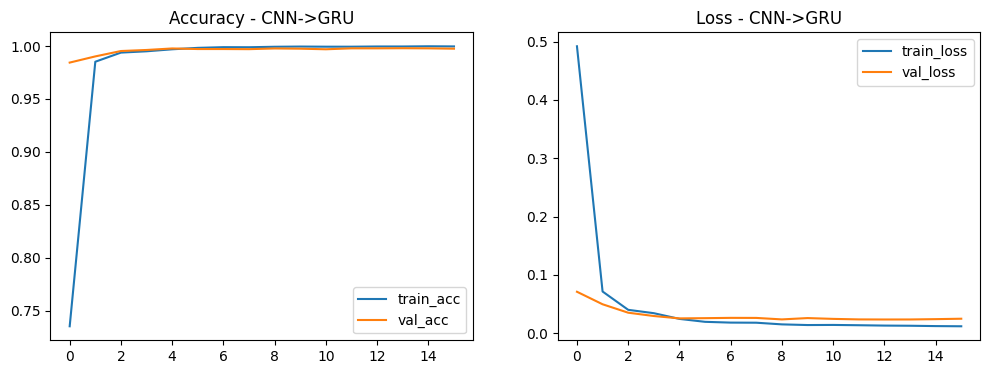

Saved model: final_cnn_gru_seq.keras


In [ ]:
# CNN -> GRU baseline (sequence windows)
art = joblib.load("preproc_stratified_final.joblib")
X_train_seq = art['X_train_seq']; y_train_seq = art['y_train_seq']
X_val_seq = art['X_val_seq']; y_val_seq = art['y_val_seq']
X_test_seq = art['X_test_seq']; y_test_seq = art['y_test_seq']
class_weights_seq = art.get('class_weights_seq', None)

def build_cnn_gru(seq_len, n_features):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.GRU(64, recurrent_dropout=0.15, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

seq_len = X_train_seq.shape[1]; n_feat = X_train_seq.shape[2]
model_gru = build_cnn_gru(seq_len, n_feat)
model_gru.summary()

es = callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6)
ckpt = callbacks.ModelCheckpoint("model_cnn_gru_seq.keras", save_best_only=True, monitor='val_auc')

history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr, ckpt],
    class_weight=class_weights_seq,
    verbose=2
)

model_gru.save("final_cnn_gru_seq.keras")

# Evaluate
eval_and_print(model_gru, X_test_seq, y_test_seq, batch_size=128, binary=True)
plot_history(history_gru, "CNN->GRU")
print("Saved model: final_cnn_gru_seq.keras")


**NOTE:** Hyperparameter is optional at this point because tuning would not significantly raise performance—maybe +0.1% at best, which is not meaningful for this dataset.

# HYBRID MODELs

In [ ]:
# Shared imports & helpers
import joblib, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
np.random.seed(42)
tf.random.set_seed(42)

def plot_history(history, title="history"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history.get('accuracy',[]), label='train_acc')
    plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
    plt.title('Accuracy - '+title); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history.get('loss',[]), label='train_loss')
    plt.plot(history.history.get('val_loss',[]), label='val_loss')
    plt.title('Loss - '+title); plt.legend()
    plt.show()

def eval_model(model, X, y, batch_size=128, binary=True):
    if X.shape[0] == 0:
        print("Empty set.")
        return
    if binary:
        y_prob = model.predict(X, batch_size=batch_size).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
        print("Accuracy:", accuracy_score(y, y_pred))
        print("F1:", f1_score(y, y_pred))
        try:
            print("AUC:", roc_auc_score(y, y_prob))
        except Exception as e:
            print("AUC could not be computed:", e)
    else:
        y_prob = model.predict(X, batch_size=batch_size)
        y_pred = np.argmax(y_prob, axis=1)
        print("Accuracy:", accuracy_score(y, y_pred))
    print("\nClassification Report:\n", classification_report(y, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))


## Hybrid CNN + LSTM (parallel branches)

Shapes: (15408, 50, 115) (9058, 50, 115) (9059, 50, 115)


Model: "hybrid_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 50, 115)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 50, 64)    │     22,144 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 50, 64)    │     22,144 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 25, 64)    │          0 │ conv1d_8[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 25, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 25, 128)   │     24,704 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 25, 128)   │     24,704 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 25, 128)   │          0 │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_7[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │    131,584 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout_5[0][0],  │
│ (Concatenate)       │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 250,369 (978.00 KB)

 Trainable params: 250,241 (977.50 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
121/121 - 24s - 198ms/step - accuracy: 0.8300 - auc: 0.9219 - loss: 0.3897 - val_accuracy: 0.6984 - val_auc: 0.9882 - val_loss: 0.9380 - learning_rate: 0.0010
Epoch 2/50
121/121 - 15s - 123ms/step - accuracy: 0.9842 - auc: 0.9968 - loss: 0.0819 - val_accuracy: 0.9511 - val_auc: 0.9984 - val_loss: 0.1625 - learning_rate: 0.0010
Epoch 3/50
121/121 - 15s - 124ms/step - accuracy: 0.9922 - auc: 0.9986 - loss: 0.0490 - val_accuracy: 0.9908 - val_auc: 0.9991 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 4/50
121/121 - 15s - 123ms/step - accuracy: 0.9970 - auc: 0.9995 - loss: 0.0300 - val_accuracy: 0.9946 - val_auc: 0.9983 - val_loss: 0.0385 - learning_rate: 0.0010
Epoch 5/50
121/121 - 15s - 124ms/step - accuracy: 0.9973 - auc: 0.9997 - loss: 0.0256 - val_accuracy: 0.9979 - val_auc: 0.9985 - val_loss: 0.0255 - learning_rate: 0.0010
Epoch 6/50
121/121 - 15s - 123ms/step - accuracy: 0.9987 - auc: 0.9998 - loss: 0.0198 - val_accuracy: 0.9979 - val_auc: 0.9988 - val_loss: 0.0254 - le

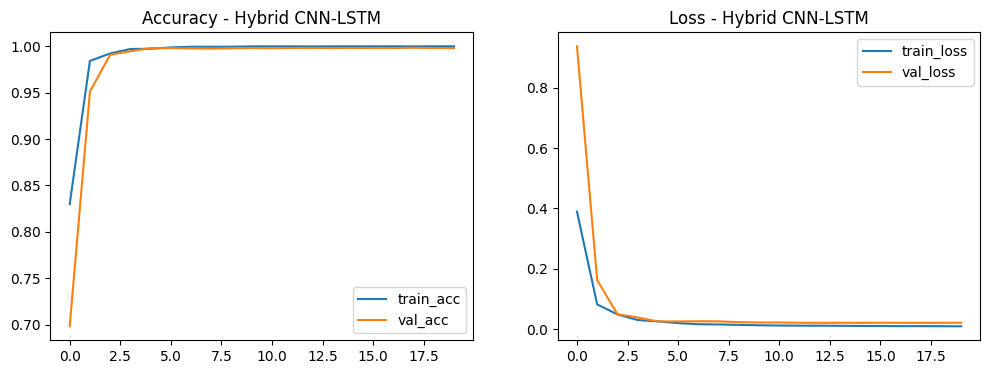

In [ ]:
# Hybrid CNN+LSTM (parallel CNN branch + LSTM branch) — sequence input
art = joblib.load("preproc_stratified_final.joblib")
X_train_seq = art['X_train_seq']; y_train_seq = art['y_train_seq']
X_val_seq   = art['X_val_seq'];   y_val_seq   = art['y_val_seq']
X_test_seq  = art['X_test_seq'];  y_test_seq  = art['y_test_seq']
class_weights_seq = art.get('class_weights_seq', None)

print("Shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

seq_len = X_train_seq.shape[1]
n_feat  = X_train_seq.shape[2]

def build_hybrid_cnn_lstm(seq_len, n_feat):
    inp = layers.Input(shape=(seq_len, n_feat), name='seq_input')

    # Branch A: CNN (local patterns -> global pool)
    a = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    a = layers.BatchNormalization()(a)
    a = layers.MaxPooling1D(2)(a)
    a = layers.Conv1D(128, 3, padding='same', activation='relu')(a)
    a = layers.GlobalAveragePooling1D()(a)
    a = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(a)
    a = layers.Dropout(0.3)(a)

    # Branch B: CNN -> LSTM (temporal)
    b = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    b = layers.MaxPooling1D(2)(b)
    b = layers.Conv1D(128, 3, padding='same', activation='relu')(b)
    b = layers.Dropout(0.2)(b)
    b = layers.LSTM(128, recurrent_dropout=0.15, kernel_regularizer=regularizers.l2(1e-4))(b)
    b = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(b)
    b = layers.Dropout(0.3)(b)

    # Combine
    x = layers.concatenate([a,b])
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inp, out, name='hybrid_cnn_lstm')
    model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

model_hybrid_lstm = build_hybrid_cnn_lstm(seq_len, n_feat)
model_hybrid_lstm.summary()

# Callbacks
es = callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6)
ckpt_path = "hybrid_cnn_lstm.keras"
mck = callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor='val_auc')

# Train (tune batch_size if OOM)
history = model_hybrid_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr, mck],
    class_weight=class_weights_seq,
    verbose=2
)

model_hybrid_lstm.save("final_hybrid_cnn_lstm.keras")
print("Saved model:", "final_hybrid_cnn_lstm.keras")

# Evaluate
print("\n--- EVALUATION ON TEST ---")
eval_model(model_hybrid_lstm, X_test_seq, y_test_seq, batch_size=128, binary=True)
plot_history(history, "Hybrid CNN-LSTM")


## Hybrid CNN + GRU (parallel branches)

Shapes: (15408, 50, 115) (9058, 50, 115) (9059, 50, 115)


Model: "hybrid_cnn_gru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 50, 115)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 50, 64)    │     22,144 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 50, 64)    │     22,144 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 25, 64)    │          0 │ conv1d_12[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 25, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 25, 128)   │     24,704 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 25, 128)   │     24,704 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 25, 128)   │          0 │ conv1d_13[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_11[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 128)       │     99,072 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dropout_9[0][0],  │
│ (Concatenate)       │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,857 (851.00 KB)

 Trainable params: 217,729 (850.50 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
121/121 - 22s - 179ms/step - accuracy: 0.8274 - auc: 0.9171 - loss: 0.4012 - val_accuracy: 0.7024 - val_auc: 0.9904 - val_loss: 0.9233 - learning_rate: 0.0010
Epoch 2/50
121/121 - 14s - 114ms/step - accuracy: 0.9838 - auc: 0.9969 - loss: 0.0820 - val_accuracy: 0.9429 - val_auc: 0.9976 - val_loss: 0.1780 - learning_rate: 0.0010
Epoch 3/50
121/121 - 14s - 114ms/step - accuracy: 0.9928 - auc: 0.9991 - loss: 0.0468 - val_accuracy: 0.9959 - val_auc: 0.9992 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 4/50
121/121 - 14s - 114ms/step - accuracy: 0.9960 - auc: 0.9995 - loss: 0.0333 - val_accuracy: 0.9966 - val_auc: 0.9988 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 5/50
121/121 - 21s - 170ms/step - accuracy: 0.9977 - auc: 0.9998 - loss: 0.0258 - val_accuracy: 0.9961 - val_auc: 0.9986 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 6/50
121/121 - 15s - 123ms/step - accuracy: 0.9990 - auc: 0.9998 - loss: 0.0198 - val_accuracy: 0.9974 - val_auc: 0.9991 - val_loss: 0.0297 - le

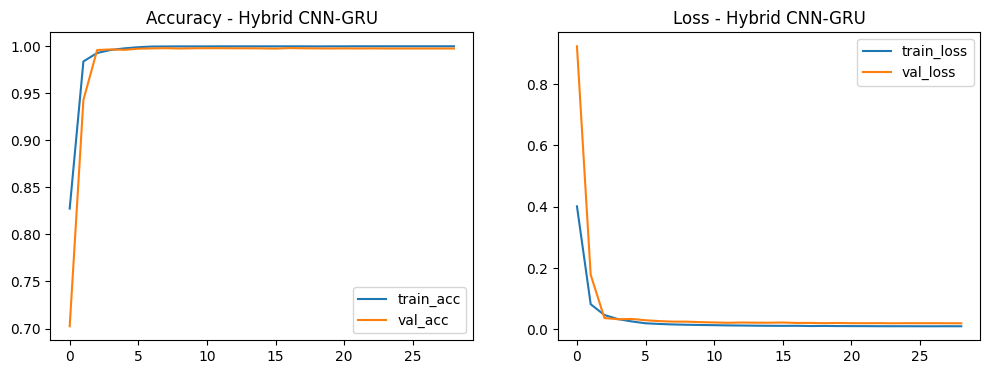

In [ ]:
# Hybrid CNN+GRU (parallel CNN branch + GRU branch) — sequence input
art = joblib.load("preproc_stratified_final.joblib")
X_train_seq = art['X_train_seq']; y_train_seq = art['y_train_seq']
X_val_seq   = art['X_val_seq'];   y_val_seq   = art['y_val_seq']
X_test_seq  = art['X_test_seq'];  y_test_seq  = art['y_test_seq']
class_weights_seq = art.get('class_weights_seq', None)

print("Shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

seq_len = X_train_seq.shape[1]
n_feat  = X_train_seq.shape[2]

def build_hybrid_cnn_gru(seq_len, n_feat):
    inp = layers.Input(shape=(seq_len, n_feat), name='seq_input')

    # Branch A: CNN (local -> pool)
    a = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    a = layers.BatchNormalization()(a)
    a = layers.MaxPooling1D(2)(a)
    a = layers.Conv1D(128, 3, padding='same', activation='relu')(a)
    a = layers.GlobalAveragePooling1D()(a)
    a = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(a)
    a = layers.Dropout(0.3)(a)

    # Branch B: CNN -> GRU (temporal)
    b = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    b = layers.MaxPooling1D(2)(b)
    b = layers.Conv1D(128, 3, padding='same', activation='relu')(b)
    b = layers.Dropout(0.2)(b)
    b = layers.GRU(128, recurrent_dropout=0.15, kernel_regularizer=regularizers.l2(1e-4))(b)
    b = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(b)
    b = layers.Dropout(0.3)(b)

    # Combine
    x = layers.concatenate([a,b])
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inp, out, name='hybrid_cnn_gru')
    model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

model_hybrid_gru = build_hybrid_cnn_gru(seq_len, n_feat)
model_hybrid_gru.summary()

# Callbacks
es = callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6)
ckpt_path = "hybrid_cnn_gru.keras"
mck = callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor='val_auc')

# Train
history_gru = model_hybrid_gru.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr, mck],
    class_weight=class_weights_seq,
    verbose=2
)

model_hybrid_gru.save("final_hybrid_cnn_gru.keras")
print("Saved model:", "final_hybrid_cnn_gru.keras")

# Evaluate
print("\n--- EVALUATION ON TEST ---")
eval_model(model_hybrid_gru, X_test_seq, y_test_seq, batch_size=128, binary=True)
plot_history(history_gru, "Hybrid CNN-GRU")
